 # Braille to Text Translation

In [2]:
import sys
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Any

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from pipeline.pipeline_model import EndToEndPipeline

pipeline = EndToEndPipeline(str(PROJECT_ROOT / "configs/pipeline_config.yaml"))

 ## 1. Reading Order Function

In [3]:
def build_formatted_text(predictions: list[dict[str, Any]], line_tolerance: float = 0.5, space_tolerance: float = 0.5) -> str:
    if not predictions:
        return "No text found."

    enriched = []
    for p in predictions:
        x1, y1, x2, y2 = p["bbox"]
        enriched.append({
            "char": p.get("char") or "?",
            "cx": (x1 + x2) / 2.0,
            "cy": (y1 + y2) / 2.0,
            "h": y2 - y1,
            "x1": x1,
            "x2": x2
        })

    enriched.sort(key=lambda x: x["cy"])
    
    lines, current_line = [], [enriched[0]]
    
    for p in enriched[1:]:
        if abs(p["cy"] - current_line[-1]["cy"]) > current_line[-1]["h"] * line_tolerance:
            lines.append(current_line)
            current_line = [p]
        else:
            current_line.append(p)
    lines.append(current_line)

    formatted_lines = []
    for line in lines:
        line.sort(key=lambda x: x["cx"])
        line_str = line[0]["char"]
        
        for prev_p, curr_p in zip(line[:-1], line[1:]):
            if (curr_p["x1"] - prev_p["x2"]) > prev_p["h"] * space_tolerance:
                line_str += " "
            line_str += curr_p["char"]
            
        formatted_lines.append(line_str)

    return "\n".join(formatted_lines)

## 2. Translate

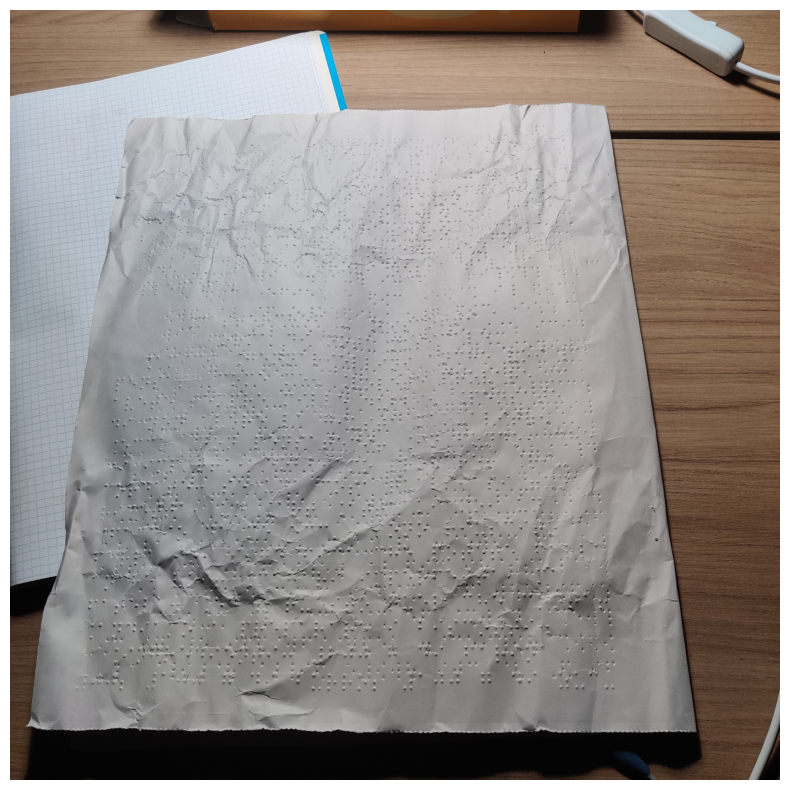


? d
i l l a
a ? ? ? r a s k
a i n q a a d h a
d e j rr o v i d e l b
? ?
? t a r c h e ?f ? ? ? b i? ? ? b t t i a
f o r m a d i n o t a m u s i c a l e ?
? ? m i c i ? g e n n a r i e l l i n i a n c h e v o i ? l c
? e o s a t h ? c o m e m e ? ? v o l e t e p r o v a r e m a
a v e t e s e m p r e m i l l e d u b b i ? ? p e n s a t e
d i n o n a v e r e l a g i u s t a ? m a o u a l i t ? ?
? e c c o ? n o n p e n s a t e c i ? ? i n ? f o n d o ? ? c h ae
? ? ? ii m p ?o r t a ? ? e o b b i a m o p r o l a r e ? ? r i ?
c o r d a t e ? s e ? u n a ? c o s a q u a l s i a s i ? u n
r i c e t t a ? u n ? a r t ? a t t a c k i ? m o ? u n
af a a ei o cc a b m e ? e c c ? ? ? s o n o r i u s c i t o ? ?
? ? ? ?
? a r b ? ? ? s ? g o i f i c a c h e p o t e t e f a ? ? ?
c h e ? ? ? i t ? ? m a g a r i i m p e r f e t t a ?
f a t e l a ? ? e n ? ? a q u e s t o q u e l ? c h e c o n t a ?
? a n d i a mm o a p r e p a r a r e i b i s c o t t i ? ? a
?
? i o g r e d i e n t i ? ? ? h j j

In [5]:
def run_translation_demo(img_path: Path | str) -> None:
    target_path = Path(img_path)
    if not target_path.exists():
        print(f"Error: couldn't find image at {target_path}")
        return

    img_bgr = cv2.imread(str(target_path))
    results = pipeline.process_image(img_bgr, translate=True)
    translated_text = build_formatted_text(results)

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
    
    print(f"\n{'=' * 50}\n{translated_text}\n{'=' * 50}\n")
    
run_translation_demo("sample1.jpg")